# Machine Learning Modeling

## Objective

The aim of this phase is to build machine learning models that can predict whether a telecom customer is likely to churn or remain with the company.

Different classification models will be trained and compared to understand:
- how well they identify churn customers,
- how class imbalance affects performance,
- and which model performs best for this problem.

Two approaches will be tested:
1. Models trained on the original dataset
2. Models trained on SMOTE-balanced data

The models to be explored include:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Classifier (SVC)
- SGDClassifier
- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost
- LightGBM
- CatBoost

Model performance will be evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC score

Special attention will be given to recall because correctly identifying customers likely to churn is more important than simply achieving high accuracy.

In [1]:
# Importing Libraries

# Data handling Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Classical ML Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Ensemble Models
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

# External boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

# Yellowbrick visualizers

from yellowbrick.classifier import (
    ConfusionMatrix,
    ROCAUC,
    ClassificationReport
)

# Ignore warnings

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load baseline datasets

X_train = pd.read_csv('/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/processed/X_train.csv')
y_train = pd.read_csv('/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/processed/y_train.csv')
X_test = pd.read_csv('/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/processed/X_test.csv')
y_test = pd.read_csv('/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/processed/y_test.csv')

# Load SMOTE datasets
X_train_smote = pd.read_csv('/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/processed/X_train_smote.csv')
y_train_smote = pd.read_csv('/home/emeka/projects/ML_Portfolio/Customer-churn-ML/data/processed/y_train_smote.csv')

# Covert target to Series
y_train_smote = y_train_smote.squeeze()
y_test = y_test.squeeze()   
y_train = y_train.squeeze()

# Verify shapes of datasets
print("Baseline Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("\nSMOTE Training Shape:", X_train_smote.shape)


Baseline Training Shape: (5634, 30)
Testing Shape: (1409, 30)

SMOTE Training Shape: (8278, 30)


# Load Processed Datasets

The datasets used in this phase were generated during preprocessing and feature engineering.

Two training versions are available:
- the original imbalanced dataset,
- and the SMOTE-balanced dataset.

The test dataset remains unchanged to ensure fair model evaluation on unseen customer data.

In [3]:
# Store model results

results = []

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):

    """
    Train and evaluate a classification model.

    Parameters
    ----------
    model : ML model
        The machine learning model to train.

    X_train : DataFrame
        Training feature data.

    y_train : Series
        Training target values.

    X_test : DataFrame
        Testing feature data.

    y_test : Series
        Actual test target values.

    model_name : str
        Name of the model.

    Returns
    -------
    metrics : dict
        Dictionary containing evaluation metrics.

    y_pred : array
        Predicted values from the model.
    """

    # Train the model

    model.fit(X_train, y_train)

    # Make predictions

    y_pred = model.predict(X_test)

    # Calculate evaluation metrics

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    # Check if model supports probability prediction

    if hasattr(model, "predict_proba"):

        # Probability of churn class (1)

        y_prob = model.predict_proba(X_test)[:, 1]

        # Calculate ROC-AUC score

        roc_auc = roc_auc_score(y_test, y_prob)

    else:

        # If model does not support probabilities

        roc_auc = np.nan

    # Save metrics in dictionary

    metrics = {

        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

    # Print results

    print(f"\nModel: {model_name}")

    print("-" * 40)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))

    if not np.isnan(roc_auc):

        print("ROC-AUC  :", round(roc_auc, 4))

    # Print classification report

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # Return metrics and predictions

    return metrics, y_pred

# Model Evaluation Function

A reusable function is created to simplify model training and evaluation.

The function will:
- train a machine learning model,
- make predictions,
- calculate evaluation metrics,
- and return the results for comparison.

This helps reduce repetitive code when testing multiple models.

In [4]:
# Check churn distribution in training data
print("Churn distribution in training data:")
print(y_train.value_counts())

Churn distribution in training data:
churn
0    4139
1    1495
Name: count, dtype: int64


In [5]:
# Percentage distribution

y_train.value_counts(normalize=True)

churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

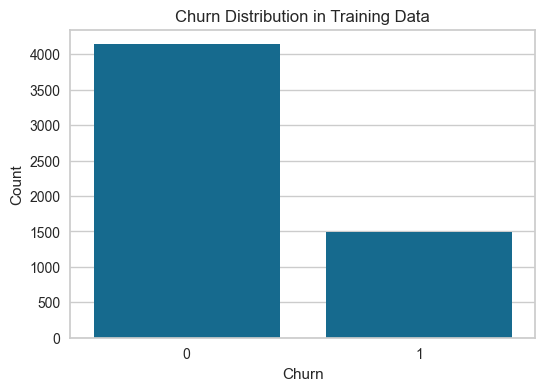

In [6]:
# Visualize churn distribution in training data
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Churn Distribution in Training Data")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


# Target Class Distribution

Before training the models, the churn distribution is examined to understand the level of class imbalance in the dataset.

This helps provide a baseline reference for evaluating model performance, especially accuracy.

# Baseline Classical Models

The following models are trained using the original imbalanced dataset to establish baseline performance:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Classifier (SVC)
- SGDClassifier
- Decision Tree
- Random Forest

These results will later be compared with models trained on SMOTE-balanced data.

In [7]:
# Classical Baseline Models

baseline_models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    'SGD Classifier': SGDClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

In [8]:
# Train and evaluate baseline models    
for name, model in baseline_models.items():

    model_metrics, y_pred = evaluate_model(model, X_train, y_train, X_test, y_test, name)

    # Store results
    results.append(model_metrics)


Model: Logistic Regression
----------------------------------------
Accuracy : 0.8041
Precision: 0.6551
Recall   : 0.5535
F1 Score : 0.6
ROC-AUC  : 0.8418

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409


Model: KNN
----------------------------------------
Accuracy : 0.7544
Precision: 0.5368
Recall   : 0.5455
F1 Score : 0.5411
ROC-AUC  : 0.782

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1035
           1       0.54      0.55      0.54       374

    accuracy                           0.75      1409
   macro avg       0.69      0.69      0.69      1409
weighted avg       0.76      0.75      0.76      1409

In [9]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804116,0.655063,0.553476,0.600000,0.841804
1,KNN,0.754436,0.536842,0.545455,0.541114,0.781996
2,SVC,0.793471,0.645614,0.491979,0.558422,0.795024
3,Decision Tree,0.730305,0.491713,0.475936,0.483696,0.648573
5,Random Forest,0.783534,0.620209,0.475936,0.538578,0.822918
4,SGD Classifier,0.786373,0.637736,0.451872,0.528951,NaN


# Baseline Classical Models

The first set of models are trained on the original imbalanced dataset to establish baseline performance.

These models will serve as a reference point before applying class balancing techniques such as SMOTE.


# Baseline Boosted Models

Boosting algorithms are trained on the original dataset to compare their performance against the classical machine learning models.

These models are designed to improve predictive performance by combining multiple weak learners.


In [10]:
# Boosted models

boosted_models = {
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

# Train and evaluate boosted models
for name, model in boosted_models.items():

    model_metrics, y_pred = evaluate_model(model, X_train, y_train, X_test, y_test, name)

    # Store results
    results.append(model_metrics)
    
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False)
results_df.round(4)


Model: AdaBoost
----------------------------------------
Accuracy : 0.8048
Precision: 0.6623
Recall   : 0.5401
F1 Score : 0.595
ROC-AUC  : 0.8407

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409


Model: Gradient Boosting
----------------------------------------
Accuracy : 0.7991
Precision: 0.6564
Recall   : 0.5107
F1 Score : 0.5744
ROC-AUC  : 0.8423

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79    

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8041,0.6551,0.5535,0.6000,0.8418
1,KNN,0.7544,0.5368,0.5455,0.5411,0.7820
9,LightGBM,0.7970,0.6384,0.5428,0.5867,0.8343
6,AdaBoost,0.8048,0.6623,0.5401,0.5950,0.8407
10,CatBoost,0.7913,0.6316,0.5134,0.5664,0.8396
7,Gradient Boosting,0.7991,0.6564,0.5107,0.5744,0.8423
8,XGBoost,0.7722,0.5831,0.4973,0.5368,0.8224
2,SVC,0.7935,0.6456,0.4920,0.5584,0.7950
3,Decision Tree,0.7303,0.4917,0.4759,0.4837,0.6486
5,Random Forest,0.7835,0.6202,0.4759,0.5386,0.8229


# Models Trained on SMOTE-Balanced Data

The same machine learning models are now trained using the SMOTE-balanced training dataset.

This helps evaluate whether balancing the minority churn class improves the model's ability to correctly identify churn customers.

# SMOTE Classical Models

The classical machine learning models are retrained using the SMOTE-balanced training dataset.

The goal is to evaluate whether balancing the minority churn class improves model performance, especially recall and churn detection capability


In [11]:
# Store SMOTE model results
smote_results = []

# Train and evaluate baseline models on SMOTE data

for name, model in baseline_models.items():

    model_metrics, y_pred = evaluate_model(model, X_train_smote, y_train_smote, X_test, y_test, name + " (SMOTE)")

    # Store results
    smote_results.append(model_metrics)
    
    # Create DataFrame for SMOTE results
smote_results_df = pd.DataFrame(smote_results)
smote_results_df = smote_results_df.sort_values(by="Recall", ascending=False)
smote_results_df.round(4)



Model: Logistic Regression (SMOTE)
----------------------------------------
Accuracy : 0.7324
Precision: 0.4974
Recall   : 0.7567
F1 Score : 0.6002
ROC-AUC  : 0.8365

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1035
           1       0.50      0.76      0.60       374

    accuracy                           0.73      1409
   macro avg       0.69      0.74      0.70      1409
weighted avg       0.79      0.73      0.75      1409


Model: KNN (SMOTE)
----------------------------------------
Accuracy : 0.7062
Precision: 0.465
Recall   : 0.7112
F1 Score : 0.5624
ROC-AUC  : 0.7713

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.70      0.78      1035
           1       0.47      0.71      0.56       374

    accuracy                           0.71      1409
   macro avg       0.67      0.71      0.67      1409
weighted avg       0.76      0.71 

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,SGD Classifier (SMOTE),0.7289,0.4932,0.7701,0.6013,NaN
0,Logistic Regression (SMOTE),0.7324,0.4974,0.7567,0.6002,0.8365
2,SVC (SMOTE),0.7509,0.5220,0.7299,0.6087,0.8169
1,KNN (SMOTE),0.7062,0.4650,0.7112,0.5624,0.7713
5,Random Forest (SMOTE),0.7686,0.5591,0.6070,0.5821,0.8213
3,Decision Tree (SMOTE),0.7268,0.4874,0.5695,0.5253,0.6763


In [12]:
print(results_df.round(4))

                  Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0   Logistic Regression    0.8041     0.6551  0.5535    0.6000   0.8418
1                   KNN    0.7544     0.5368  0.5455    0.5411   0.7820
9              LightGBM    0.7970     0.6384  0.5428    0.5867   0.8343
6              AdaBoost    0.8048     0.6623  0.5401    0.5950   0.8407
10             CatBoost    0.7913     0.6316  0.5134    0.5664   0.8396
7     Gradient Boosting    0.7991     0.6564  0.5107    0.5744   0.8423
8               XGBoost    0.7722     0.5831  0.4973    0.5368   0.8224
2                   SVC    0.7935     0.6456  0.4920    0.5584   0.7950
3         Decision Tree    0.7303     0.4917  0.4759    0.4837   0.6486
5         Random Forest    0.7835     0.6202  0.4759    0.5386   0.8229
4        SGD Classifier    0.7864     0.6377  0.4519    0.5290      NaN


# SMOTE Boosted Models

Boosting models are retrained using the SMOTE-balanced training dataset to evaluate whether class balancing further improves churn prediction performance.

The focus remains on improving recall while maintaining reasonable precision and ROC-AUC performance.


In [13]:
# train and evaluate boosted models on SMOTE data
for name, model in boosted_models.items():
    
    model_metrics, y_pred = evaluate_model(model, X_train_smote, y_train_smote, X_test, y_test, name + " (SMOTE)")

    # Store results
    smote_results.append(model_metrics)
    
# Create DataFrame for SMOTE results
smote_results_df = pd.DataFrame(smote_results)
smote_results_df = smote_results_df.sort_values(by="Recall", ascending=False)
smote_results_df.round(4)


Model: AdaBoost (SMOTE)
----------------------------------------
Accuracy : 0.7516
Precision: 0.5218
Recall   : 0.7674
F1 Score : 0.6212
ROC-AUC  : 0.8409

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409


Model: Gradient Boosting (SMOTE)
----------------------------------------
Accuracy : 0.7736
Precision: 0.5565
Recall   : 0.7246
F1 Score : 0.6295
ROC-AUC  : 0.8396

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,SGD Classifier (SMOTE),0.7289,0.4932,0.7701,0.6013,NaN
6,AdaBoost (SMOTE),0.7516,0.5218,0.7674,0.6212,0.8409
0,Logistic Regression (SMOTE),0.7324,0.4974,0.7567,0.6002,0.8365
2,SVC (SMOTE),0.7509,0.5220,0.7299,0.6087,0.8169
7,Gradient Boosting (SMOTE),0.7736,0.5565,0.7246,0.6295,0.8396
1,KNN (SMOTE),0.7062,0.4650,0.7112,0.5624,0.7713
9,LightGBM (SMOTE),0.7679,0.5545,0.6390,0.5938,0.8330
10,CatBoost (SMOTE),0.7700,0.5595,0.6283,0.5919,0.8347
8,XGBoost (SMOTE),0.7743,0.5690,0.6176,0.5923,0.8179
5,Random Forest (SMOTE),0.7686,0.5591,0.6070,0.5821,0.8213


# Model Comparison

The models trained on both the original and SMOTE-balanced datasets are compared using recall, F1-score, and ROC-AUC metrics.

Special attention is given to recall because correctly identifying churn customers is the primary business objective.


In [14]:
# Concatenate all results
all_results_df = pd.concat([results_df, smote_results_df], ignore_index=True, axis=0)
all_results_df = all_results_df.sort_values(by="Recall", ascending=False)
all_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
11,SGD Classifier (SMOTE),0.7289,0.4932,0.7701,0.6013,NaN
12,AdaBoost (SMOTE),0.7516,0.5218,0.7674,0.6212,0.8409
13,Logistic Regression (SMOTE),0.7324,0.4974,0.7567,0.6002,0.8365
14,SVC (SMOTE),0.7509,0.5220,0.7299,0.6087,0.8169
15,Gradient Boosting (SMOTE),0.7736,0.5565,0.7246,0.6295,0.8396
16,KNN (SMOTE),0.7062,0.4650,0.7112,0.5624,0.7713
17,LightGBM (SMOTE),0.7679,0.5545,0.6390,0.5938,0.8330
18,CatBoost (SMOTE),0.7700,0.5595,0.6283,0.5919,0.8347
19,XGBoost (SMOTE),0.7743,0.5690,0.6176,0.5923,0.8179
20,Random Forest (SMOTE),0.7686,0.5591,0.6070,0.5821,0.8213


# Model Comparison Visualization

The performance of the trained models is visualized to compare recall, F1-score, and ROC-AUC across both baseline and SMOTE-trained models.

This provides a clearer understanding of the tradeoffs between churn detection performance and prediction reliability.


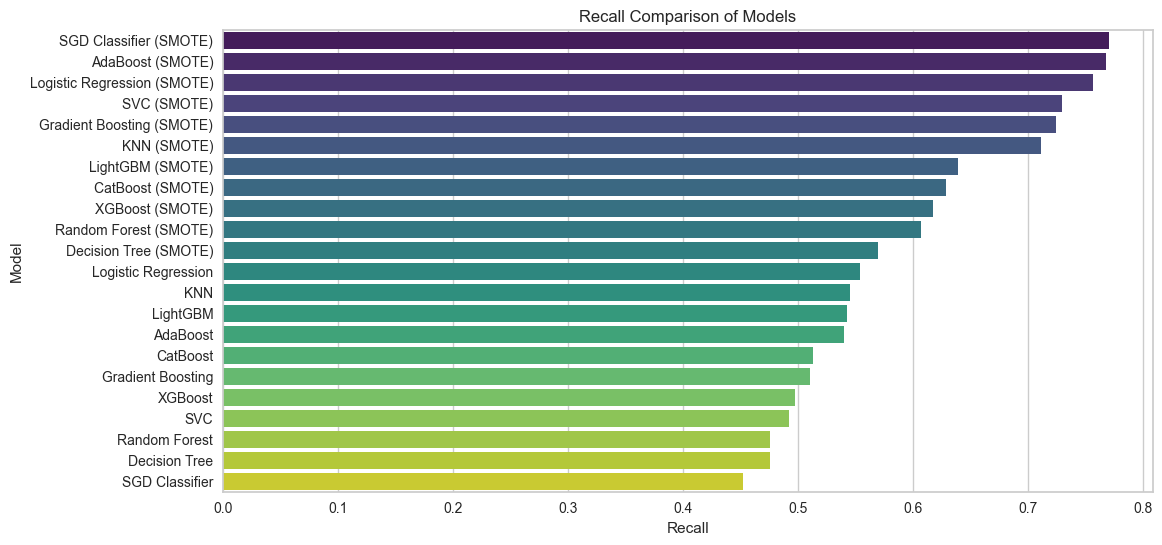

In [48]:
# Model Visualization- Recall Comparison
plt.figure(figsize=(12, 6))
sns.barplot(x="Recall", y="Model", data=all_results_df, palette="viridis")
plt.title("Recall Comparison of Models")
plt.xlabel("Recall")
plt.ylabel("Model")
plt.savefig("../visual/recall_comparison.png")
plt.show()

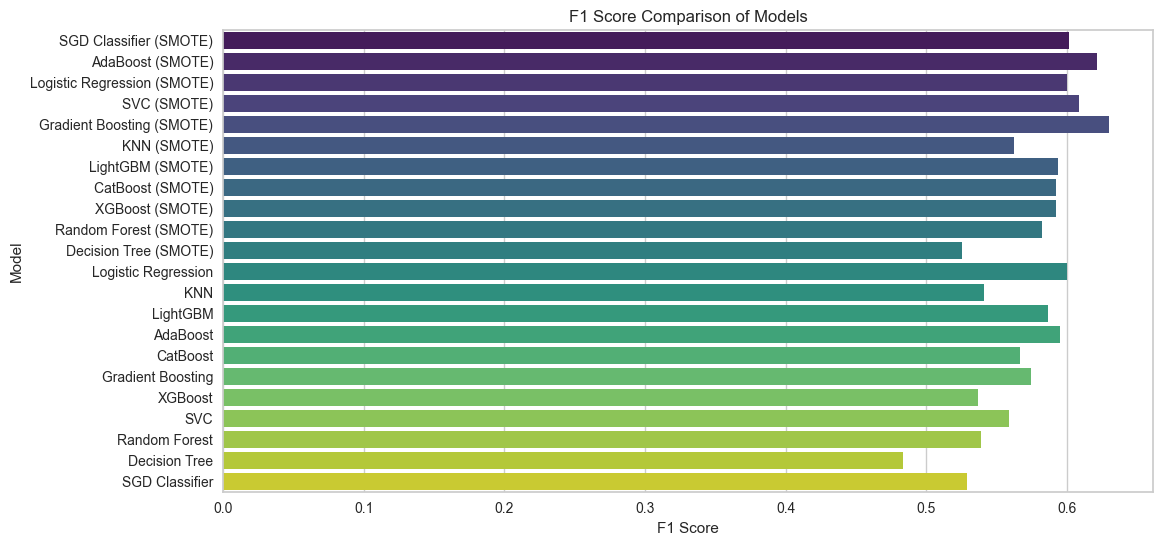

In [47]:
# Model Comparison Visualization-F1 Score Comparison
plt.figure(figsize=(12, 6))
sns.barplot(x="F1 Score", y="Model", data=all_results_df, palette="viridis")
plt.title("F1 Score Comparison of Models")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.savefig("../visual/f1_score_comparison.png")
plt.show()

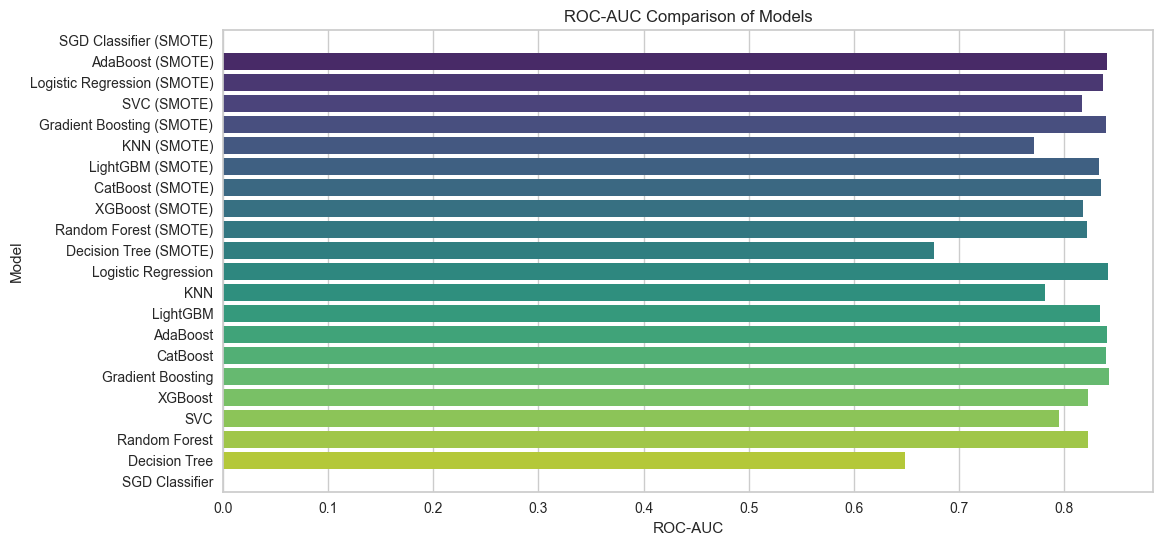

In [46]:
# Visualize model performance-ROC-AUC Comparison
plt.figure(figsize=(12, 6))
sns.barplot(x="ROC-AUC", y="Model", data=all_results_df, palette="viridis")
plt.title("ROC-AUC Comparison of Models")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.savefig("../visual/roc_auc_comparison.png")
plt.show()


# Model Comparison Insights

## Recall Comparison

From the recall comparison chart, the SMOTE-trained models significantly outperformed the baseline models in churn detection capability.

- SGDClassifier (SMOTE) achieved the highest recall, followed closely by AdaBoost (SMOTE) and Logistic Regression (SMOTE).
- SVC (SMOTE) and Gradient Boosting (SMOTE) also demonstrated strong recall performance.
- The baseline versions of SGDClassifier, Decision Tree, and Random Forest produced the weakest recall scores, indicating that the imbalanced dataset negatively affected their ability to identify churn customers.

These results confirm that applying SMOTE substantially improved the models’ ability to detect minority churn cases.

---

## F1-Score Comparison

The F1-score comparison shows that Gradient Boosting (SMOTE) achieved the strongest balance between precision and recall.

- AdaBoost (SMOTE), SVC (SMOTE), and Logistic Regression (SMOTE) also demonstrated competitive F1-score performance.
- Logistic Regression remained one of the most stable models across both baseline and SMOTE datasets.
- Decision Tree (baseline) produced the weakest F1-score, indicating poor overall classification balance.

The results suggest that boosting models combined with SMOTE provide more balanced churn prediction performance.

---

## ROC-AUC Comparison

Most models achieved relatively strong ROC-AUC scores, particularly the SMOTE-trained boosting models.

- Gradient Boosting (SMOTE), AdaBoost (SMOTE), Logistic Regression, and CatBoost demonstrated strong class separation capability.
- The high ROC-AUC values indicate that these models are effective at distinguishing churn customers from non-churn customers across different classification thresholds.
- Decision Tree consistently produced the weakest ROC-AUC score, suggesting poor class separation performance.

Overall, the results indicate that SMOTE improved churn detection performance while boosting algorithms improved the models’ ability to separate customer classes effectively..


# Model Selection

Based on the comparison results, the top-performing models are selected for further evaluation and hyperparameter tuning.

Model selection is primarily based on:
- recall performance,
- F1-score balance,
- and ROC-AUC performance.

Special attention is given to recall because the primary business objective is to correctly identify customers likely to churn.


In [18]:
# Select top Models

top_models = all_results_df[all_results_df['Model'].isin([
                                                            'Gradient Boosting (SMOTE)',
                                                            'AdaBoost (SMOTE)',
                                                            'Logistic Regression (SMOTE)',
                                                            'SVC (SMOTE)'
                                                        ])]

top_models.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
12,AdaBoost (SMOTE),0.7516,0.5218,0.7674,0.6212,0.8409
13,Logistic Regression (SMOTE),0.7324,0.4974,0.7567,0.6002,0.8365
14,SVC (SMOTE),0.7509,0.5220,0.7299,0.6087,0.8169
15,Gradient Boosting (SMOTE),0.7736,0.5565,0.7246,0.6295,0.8396


# Confusion Matrix Evaluation

The selected top-performing models are further evaluated using confusion matrices.

This provides a clearer understanding of:
- correctly predicted churn customers,
- missed churn customers,
- false churn alerts,
- and overall model prediction behavior.

Special attention is given to false negatives because missed churn customers directly affect customer retention efforts.


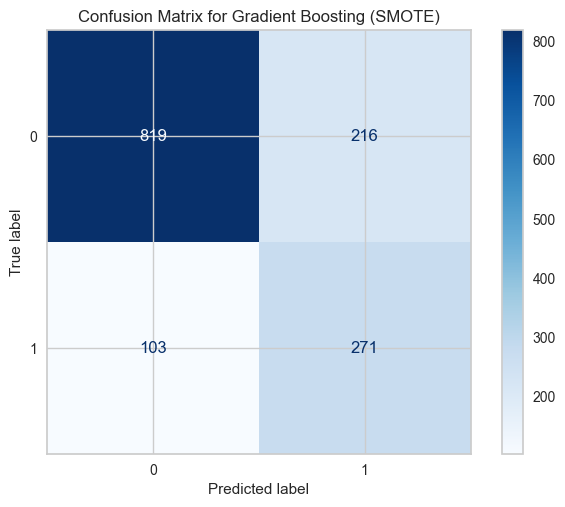

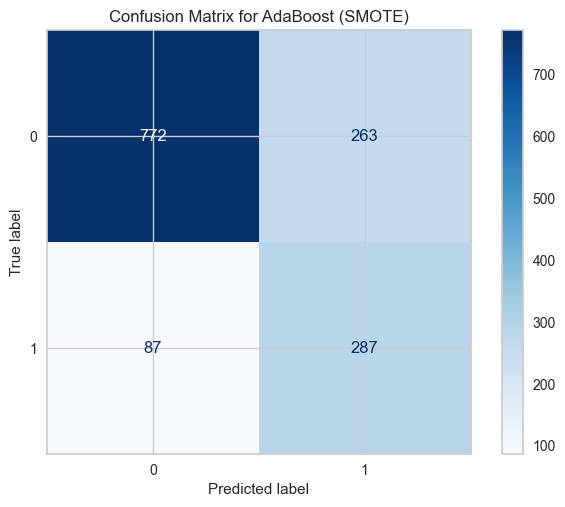

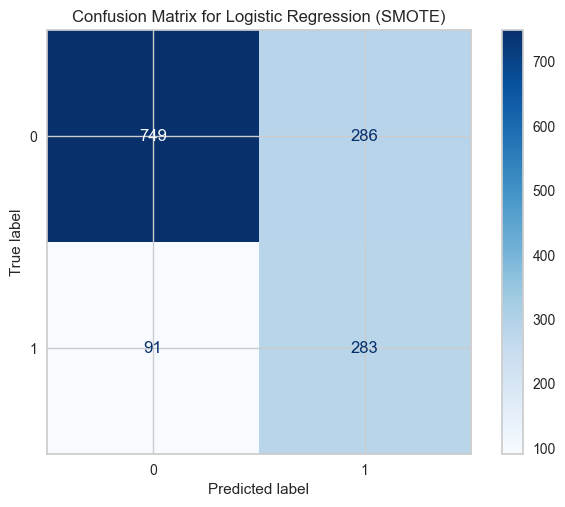

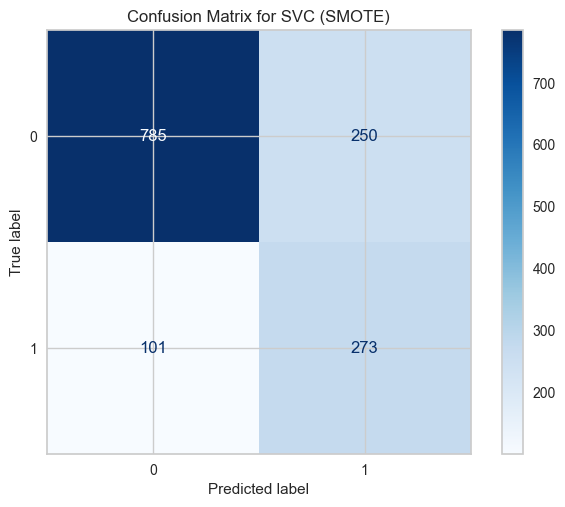

In [45]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Selected top_performing model_metrics
selected_models = {
    'Gradient Boosting (SMOTE)': GradientBoostingClassifier(random_state=42),
    'AdaBoost (SMOTE)': AdaBoostClassifier(random_state=42),
    'Logistic Regression (SMOTE)': LogisticRegression(random_state=42),
    'SVC (SMOTE)': SVC(probability=True, random_state=42)
}

# Confusion metrix evaluation
for name, model in selected_models.items():

    # Train the model on SMOTE data
    model.fit(X_train_smote, y_train_smote)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix for {name}")
    plt.savefig(f"../visual/confusion_matrix_{name.replace(' ', '_')}.png")
    plt.show()


# Confusion Matrix Insights

The confusion matrix evaluation provided deeper insight into how the selected models handled churn prediction errors.

## False Negatives Analysis

False negatives represent actual churn customers incorrectly predicted as non-churn customers.

This is particularly important because:
- missed churn customers may leave without intervention,
- directly affecting customer retention efforts.

Among the evaluated models:

- AdaBoost (SMOTE) produced the lowest number of false negatives, indicating the strongest churn detection capability.
- Logistic Regression (SMOTE) and SVC (SMOTE) also demonstrated relatively strong churn detection performance.
- Gradient Boosting (SMOTE) produced the highest false negatives among the selected models, suggesting that more churn customers were missed despite its strong overall balance.

---

## False Positives Analysis

False positives represent loyal customers incorrectly predicted as churn customers.

Although false positives may increase unnecessary retention efforts, they are generally less costly than missed churn customers.

From the confusion matrices:

- Gradient Boosting (SMOTE) produced the lowest false positives, indicating stronger prediction precision.
- SVC (SMOTE) also maintained relatively lower false positive counts.
- AdaBoost (SMOTE) and Logistic Regression (SMOTE) produced higher false positive counts as a tradeoff for improved churn detection.

---

## Overall Observation

The confusion matrices further confirmed the earlier model comparison results:

- AdaBoost (SMOTE) demonstrated the strongest churn detection performance.
- Gradient Boosting (SMOTE) maintained the best overall balance between precision and recall.
- Logistic Regression (SMOTE) remained a stable and interpretable model with competitive performance.
- SVC (SMOTE) also showed balanced classification behavior across both churn and non-churn classes.

These results highlight the tradeoff between minimizing missed churn customers and reducing false churn alerts.



# ROC Curve Evaluation

ROC curves are used to evaluate the ability of the selected models to distinguish between churn and non-churn customers across different classification thresholds.

The ROC-AUC score measures how well a model separates the two classes:
- higher ROC-AUC values indicate better class discrimination,
- while lower values indicate weaker separation performance.

ROC curve analysis provides additional insight into the overall classification strength of each selected model.


<Figure size 1200x800 with 0 Axes>

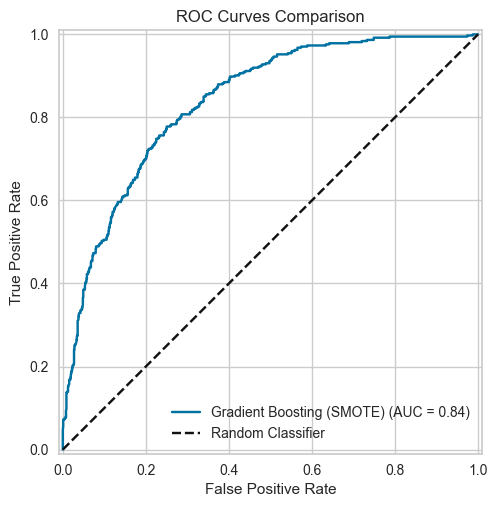

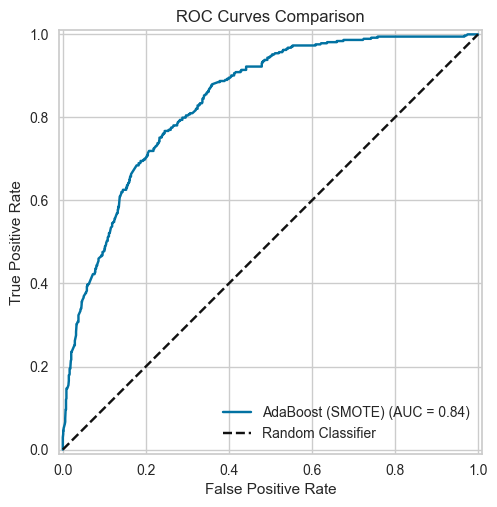

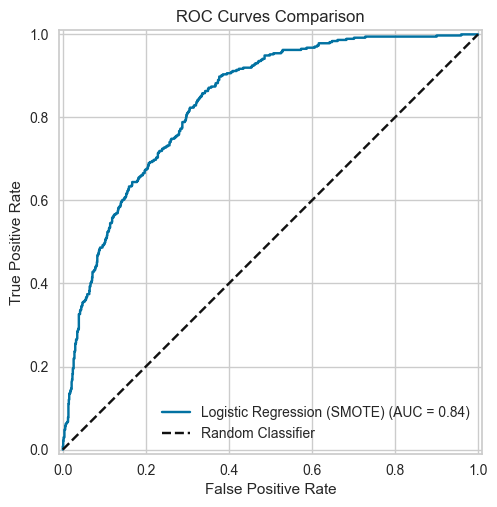

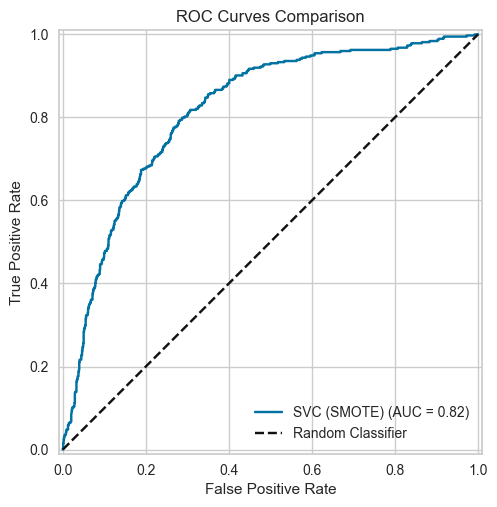

In [44]:
from sklearn.metrics import RocCurveDisplay

# ROC Curve Evaluation
plt.figure(figsize=(12, 8))
for name, model in selected_models.items():

    # Train the model on SMOTE data
    model.fit(X_train_smote, y_train_smote)

    
    # Plot ROC curve
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name)
    
    # plot reference line
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Title and labels
    plt.title("ROC Curves Comparison")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.savefig("../visual/roc_curves_comparison.png")
    plt.show();

# ROC Curve Interpretation

From the ROC curve evaluation, most of the selected SMOTE models achieved a ROC-AUC score of approximately 0.84, while SVC achieved about 0.82.

This indicates that the models generally have a strong ability to distinguish between churn and non-churn customers.

The ROC curves are positioned well above the diagonal baseline, confirming that the models perform significantly better than random guessing.

Among the evaluated models:
- AdaBoost (SMOTE),
- Gradient Boosting (SMOTE),
- and Logistic Regression (SMOTE)

showed the strongest overall class separation performance.

Although SVC (SMOTE) performed slightly lower, its ROC-AUC score still indicates good classification capability.

Overall, the ROC analysis supports earlier findings from the Recall, F1 Score, and Confusion Matrix evaluations that the SMOTE-based models provide stronger churn detection performance compared to the baseline models.


# **Hyperparameter Tunning**
In this section, hyperparameter tuning is performed to improve the performance of the best-performing models identified during model comparison.

The objective is to:
- improve churn prediction performance,
- reduce false negatives,
- improve recall and F1-score,
- and optimize overall model generalization.

Gradient Boosting (SMOTE) was selected as the first model for tuning because it demonstrated strong overall performance across Recall, F1 Score, ROC-AUC, and confusion matrix evaluation.


In [21]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report


In [22]:
# Create a list to store tuned model results
tuned_results = []

def evaluate_tuned_model(model_name, y_test, y_pred, y_prob):
    
    """
    Evaluates tuned model performance and stores results.

    Parameters:
    ----------
    model_name : str
        Name of tuned model

    y_test : array-like
        Actual target values

    y_pred : array-like
        Predicted class labels

    y_prob : array-like
        Predicted probabilities

    Returns:
    -------
    None
    """

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    tuned_results.append(result)


In [23]:
# Expanded parameter space for Gradient Boosting

gb_random_params = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.8, 1.0]
}

# Create RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(estimator=GradientBoostingClassifier(random_state=42),
                                   param_distributions=gb_random_params,
                                   n_iter=50,
                                   cv=5,
                                   scoring='recall',
                                   n_jobs=-1,
                                   random_state=42,
                                   verbose=1)

# Fit RandomizedSearchCV on SMOTE training data
random_search.fit(X_train_smote, y_train_smote)

# Best hyperparameters from RandomizedSearchCV
print("Best Hyperparameters from RandomizedSearchCV:", random_search.best_params_)

# Best cross-validation score from RandomizedSearchCV
print("Best CV Score from RandomizedSearchCV:", round(random_search.best_score_, 4))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters from RandomizedSearchCV: {'subsample': 1.0, 'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 2, 'learning_rate': 0.01}
Best CV Score from RandomizedSearchCV: 0.8666


In [24]:
# Predict probabilities
y_prob_gb = random_search.predict_proba(X_test)[:, 1]

# Evaluate tuned model performance
result = evaluate_tuned_model("Gradient Boosting (Tuned)", y_test, random_search.predict(X_test), y_prob_gb)

# Store tuned model results
tuned_results.append(result)

tuned_results

[{'Model': 'Gradient Boosting (Tuned)',
  'Accuracy': 0.7295954577714692,
  'Precision': 0.49432739059967584,
  'Recall': 0.8155080213903744,
  'F1 Score': 0.615539858728557,
  'ROC-AUC': 0.8266992172363017},
 None]

In [25]:
# AdaBoost Hyperparameter Tuning

ada_random_params = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.03, 0.05, 0.1]
}

# Create RandomizedSearchCV for AdaBoost
ada_random_search = RandomizedSearchCV(estimator=AdaBoostClassifier(random_state=42),
                                      param_distributions=ada_random_params,
                                      n_iter=50,
                                      cv=5,
                                      scoring='recall',
                                        n_jobs=-1,
                                        verbose=1)

# Fit RandomizedSearchCV on SMOTE training data
ada_random_search.fit(X_train_smote, y_train_smote)

# Best hyperparameters from RandomizedSearchCV
print("Best Hyperparameters from RandomizedSearchCV for AdaBoost:", ada_random_search.best_params_)

# Best cross-validation score from RandomizedSearchCV
print("Best CV Score from RandomizedSearchCV for AdaBoost:", round(ada_random_search.best_score_, 4))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Hyperparameters from RandomizedSearchCV for AdaBoost: {'n_estimators': 50, 'learning_rate': 0.01}
Best CV Score from RandomizedSearchCV for AdaBoost: 0.9831


In [26]:
# Best AdaBoost model
best_ada_model = ada_random_search.best_estimator_

# Predictions
y_prob_ada = best_ada_model.predict_proba(X_test)[:, 1]
y_pred_ada = best_ada_model.predict(X_test)

# Store tuned AdaBoost results
ada_result = evaluate_tuned_model("AdaBoost (Tuned)", y_test, y_pred_ada, y_prob_ada)
tuned_results.append(ada_result)    

In [27]:
# LogisticRegression parameter space
logistic_random_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ['l1', 'l2', 'elasticnet', 'none'],  
    "solver": ['liblinear', 'saga', 'lbfgs', 'newton-cg']
}

# Create RandomizedSearchCV for Logistic Regression
logistic_random_search = RandomizedSearchCV(estimator=LogisticRegression(random_state=42),
                                           param_distributions=logistic_random_params,
                                           n_iter=50,
                                           cv=5,
                                           scoring='recall',
                                           n_jobs=-1,
                                           random_state=42,
                                           verbose=1)   
# Fit RandomizedSearchCV on SMOTE training data
logistic_random_search.fit(X_train_smote, y_train_smote)

# Best hyperparameters from RandomizedSearchCV
print("Best Hyperparameters from RandomizedSearchCV for Logistic Regression:", logistic_random_search.best_params_) 

# Best cross-validation score from RandomizedSearchCV
print("Best CV Score from RandomizedSearchCV for Logistic Regression:", round(logistic_random_search.best_score_, 4))



Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Hyperparameters from RandomizedSearchCV for Logistic Regression: {'solver': 'newton-cg', 'penalty': 'l2', 'C': 10}
Best CV Score from RandomizedSearchCV for Logistic Regression: 0.8144


In [28]:
# Best model from RandomizedSearchCV
best_logistic_model = logistic_random_search.best_estimator_

# Predictions
y_prob_logistic = best_logistic_model.predict_proba(X_test)[:, 1]
y_pred_logistic = best_logistic_model.predict(X_test)

# store tuned Logistic Regression results
logistic_result = evaluate_tuned_model("Logistic Regression (Tuned)", y_test, y_pred_logistic, y_prob_logistic)
tuned_results.append(logistic_result)   

In [29]:
# SVC parameter space
svc_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "kernel": ['linear', 'poly'],
    "gamma": ['scale', 'auto']
}

# create RandomizedSearchCV for SVC
svc_random_search = RandomizedSearchCV(estimator=SVC(probability=True, random_state=42),
                                      param_distributions=svc_params,
                                      n_iter=50,
                                      cv=5,
                                      scoring='recall',
                                      n_jobs=-1,
                                      random_state=42,
                                      verbose=1)

# Fit RandomizedSearchCV on SMOTE training data
svc_random_search.fit(X_train_smote, y_train_smote)

# Best hyperparameters from RandomizedSearchCV
print("Best Hyperparameters from RandomizedSearchCV for SVC:", svc_random_search.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters from RandomizedSearchCV for SVC: {'kernel': 'poly', 'gamma': 'auto', 'C': 0.1}


In [30]:
# Best model from RandomizedSearchCV
best_svc_model = svc_random_search.best_estimator_

# Predictions
y_prob_svc = best_svc_model.predict_proba(X_test)[:, 1]
y_pred_svc = best_svc_model.predict(X_test) 

# store tuned SVC results
svc_result = evaluate_tuned_model("SVC (Tuned)", y_test, y_pred_svc, y_prob_svc)
tuned_results.append(svc_result)

In [32]:
# Remove None values
tuned_results = [result for result in tuned_results if result is not None]

# Tunned results table
tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df.sort_values(by="Recall", ascending=False)
tuned_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,AdaBoost (Tuned),0.4911,0.3402,0.9759,0.5045,0.7587
3,SVC (Tuned),0.5827,0.3784,0.8904,0.5311,0.8074
0,Gradient Boosting (Tuned),0.7296,0.4943,0.8155,0.6155,0.8267
2,Logistic Regression (Tuned),0.7331,0.4982,0.7567,0.6008,0.8362


## Final Tuned Model Selection

After hyperparameter tuning using RandomizedSearchCV optimized for recall, the tuned models were compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Although AdaBoost achieved the highest recall score, it showed very low precision and accuracy, indicating that the model classified too many customers as churners, leading to a high number of false positives.

SVC also achieved strong recall performance but showed lower overall stability and higher computational cost during tuning.

Gradient Boosting achieved the best overall balance between recall, F1-score, ROC-AUC, and accuracy. The model was able to identify churn customers effectively while maintaining a more stable and balanced prediction performance.

Logistic Regression also performed strongly with competitive ROC-AUC and precision scores, making it a highly interpretable and reliable model.

Overall, Gradient Boosting was selected as the final model because it provided the best tradeoff between identifying churn customers and minimizing excessive false alarms.

### Key Observations

- AdaBoost achieved the highest recall but generated too many false positives.
- SVC showed competitive recall but required significantly longer computational time.
- Logistic Regression remained highly stable and interpretable with strong ROC-AUC performance.
- Gradient Boosting provided the best balance across multiple evaluation metrics.

### Final Selected Model

**Gradient Boosting (SMOTE)** was selected as the final model for customer churn prediction because of its balanced performance across recall, F1-score, ROC-AUC, and overall stability.


# Tuned VS Untuned Model Comparison

In [34]:
top_models['Version'] = 'Untuned'
tuned_results_df['Version'] = 'Tuned'

# Concatenate top models with tuned results
final_comparison_df = pd.concat([top_models, tuned_results_df], ignore_index=True, axis=0)
final_comparison_df = final_comparison_df.sort_values(by="Recall", ascending=False)
final_comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Version
4,AdaBoost (Tuned),0.4911,0.3402,0.9759,0.5045,0.7587,Tuned
5,SVC (Tuned),0.5827,0.3784,0.8904,0.5311,0.8074,Tuned
6,Gradient Boosting (Tuned),0.7296,0.4943,0.8155,0.6155,0.8267,Tuned
0,AdaBoost (SMOTE),0.7516,0.5218,0.7674,0.6212,0.8409,Untuned
1,Logistic Regression (SMOTE),0.7324,0.4974,0.7567,0.6002,0.8365,Untuned
7,Logistic Regression (Tuned),0.7331,0.4982,0.7567,0.6008,0.8362,Tuned
2,SVC (SMOTE),0.7509,0.5220,0.7299,0.6087,0.8169,Untuned
3,Gradient Boosting (SMOTE),0.7736,0.5565,0.7246,0.6295,0.8396,Untuned


## Tuned vs Untuned Model Comparison

After comparing the tuned and untuned versions of the top-performing models, it was observed that hyperparameter tuning did not consistently improve overall model performance.

Although some tuned models achieved significantly higher recall scores, this often came at the expense of precision, F1-score, and ROC-AUC performance. This indicates that some tuned models became overly sensitive to the minority churn class, leading to a high number of false positives.

For example, the tuned AdaBoost model achieved the highest recall score of 97.59%, meaning it was able to detect nearly all churn customers. However, its precision dropped substantially to 34.02%, indicating that many non-churn customers were incorrectly classified as churners.

On the other hand, the untuned models provided a more balanced performance across multiple evaluation metrics.

Gradient Boosting (SMOTE - Untuned) achieved:

- Strong Recall Score
- Highest F1-Score
- Strong Precision
- High ROC-AUC Score
- Better balance between churn detection and false alarms

This suggests that the untuned Gradient Boosting model generalized better on unseen data compared to its tuned counterpart.

Overall, the comparison demonstrates that hyperparameter tuning does not always guarantee better performance, especially when optimizing heavily toward a single metric such as recall.



# Final Model Selection

The primary business objective of this project is to identify customers who are likely to churn while maintaining a reasonable balance between correctly identifying churners and minimizing false alarms.

Although the tuned AdaBoost model achieved the highest recall score, its very low precision indicated that the model generated too many false positive predictions, making it less practical for real-world deployment.

After evaluating all tuned and untuned models using Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix, and ROC Curve analysis, the untuned Gradient Boosting (SMOTE) model was selected as the final model.

## Reasons for Selecting Gradient Boosting (SMOTE)

- Achieved the highest F1-Score among the final competing models
- Maintained strong ROC-AUC performance
- Produced better balance between Precision and Recall
- Reduced false alarms compared to highly recall-focused models
- Demonstrated more stable and generalized performance on unseen data

## Final Selected Model

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---|---|---|---|---|---|
| Gradient Boosting (SMOTE) | 0.7736 | 0.5565 | 0.7246 | 0.6295 | 0.8396 |

This model provides the best trade-off between identifying churn customers and maintaining reliable prediction quality, making it the most suitable model for customer churn prediction in this project.


# Feature Importance Analysis

Feature importance analysis was conducted on the final selected model — Gradient Boosting (SMOTE) — to identify the variables that contributed most to customer churn prediction.

Understanding feature importance is critical because it helps explain the factors driving customer churn and provides actionable business insights for retention strategies.

The Gradient Boosting model assigns an importance score to each feature based on how much the feature contributes to reducing prediction error during model training.

Features with higher importance scores have greater influence on the model’s prediction decisions.

This analysis helps answer key business questions such as:

- Which customer characteristics contribute most to churn?
- Which services or behaviors are associated with higher churn risk?
- What factors should the business focus on to improve customer retention?

The top important features identified by the model will be visualized and interpreted in the following section.


In [35]:
# Final Selected Model
final_model = GradientBoostingClassifier(random_state=42)

# Train on SMOTE data
final_model.fit(X_train_smote, y_train_smote)

# Create feature importance dataframe
feature_importance = pd.DataFrame({
                                    "Feature": X_train_smote.columns,
                                     "Importance": final_model.feature_importances_
                                    }).sort_values(by="Importance", ascending=False)

feature_importance.head()

,Feature,Importance
26,contract_Two year,0.222937
4,tenure,0.155300
25,contract_One year,0.154332
11,internetservice_Fiber optic,0.102847
28,paymentmethod_Electronic check,0.092399


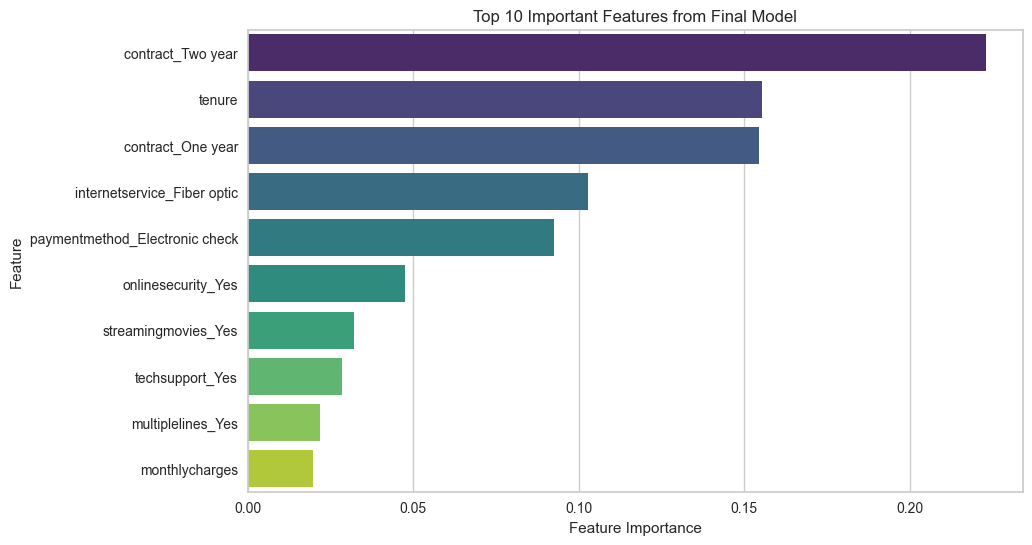

In [42]:
# Display top 10 important features
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance.head(10), palette="viridis")
plt.title("Top 10 Important Features from Final Model")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.savefig("../visual/top_10_important_features.png")
plt.show()

## Feature Importance Interpretation

The feature importance analysis revealed that customer contract type and customer tenure were the strongest predictors of customer churn.

Among all variables, `contract_Two year` had the highest importance score, indicating that customers with longer contract commitments are significantly less likely to churn. Similarly, `contract_One year` also showed strong influence on churn prediction, further confirming that contract duration plays a major role in customer retention.

Customer tenure was identified as another highly important feature. This suggests that newer customers are more likely to churn compared to long-term customers who have remained with the company for a longer period.

The analysis also showed that customers using Fiber Optic internet services contributed strongly to churn prediction. This may indicate possible dissatisfaction related to pricing, service quality, or customer expectations associated with fiber internet services.

Payment method through Electronic Check also appeared as an important churn factor, suggesting that customers using this payment option may have higher churn tendencies compared to customers using more automated or stable payment methods.

Additional features such as online security, tech support, streaming movies, multiple lines, and monthly charges also contributed to churn prediction, although with lower importance scores.

Overall, the analysis indicates that customer retention is strongly influenced by:

- Contract duration
- Customer loyalty and tenure
- Internet service type
- Payment methods
- Value-added customer support services

These findings provide actionable business insights that can help the company design more effective customer retention strategies.


# **Key Business Insights**

The machine learning analysis revealed several important factors influencing customer churn.

## Contract Type Strongly Influences Churn

Customers with month-to-month contracts showed higher churn tendencies, while customers on one-year and two-year contracts were significantly more likely to remain with the company. This suggests that long-term contractual commitments improve customer retention and loyalty.

## Newer Customers Are More Likely to Churn

Customer tenure emerged as one of the strongest predictors of churn. Customers with shorter tenure were more likely to leave the company compared to long-term customers. This indicates that the early stages of the customer lifecycle are critical for retention efforts.

## Fiber Optic Internet Customers Show Higher Churn Risk

Customers using fiber optic internet services contributed strongly to churn prediction. This may suggest potential dissatisfaction related to pricing, customer expectations, or service quality among fiber optic subscribers.

## Payment Method Influences Churn Behavior

Customers using electronic check payment methods showed higher churn tendencies compared to customers using more stable or automated payment methods. This may indicate lower customer commitment or payment convenience issues.

## Customer Support Services Affect Retention

Features such as online security and tech support also influenced churn prediction. Customers without additional support and security services may be more likely to churn, suggesting that value-added services contribute positively to customer satisfaction and retention.



# **Business Recommendations**

Based on the findings from the machine learning analysis, the following recommendations are proposed to reduce customer churn and improve customer retention.

## Encourage Long-Term Contracts

The company should promote one-year and two-year contract plans through discounts, loyalty rewards, or bundled offers. Since long-term contracts are associated with lower churn, encouraging customers to move away from month-to-month plans may improve retention.

## Improve Early Customer Engagement

Since newer customers are more likely to churn, the company should strengthen onboarding processes and early customer engagement programs. Providing personalized support during the first few months may improve customer satisfaction and loyalty.

## Investigate Fiber Optic Customer Experience

The company should further investigate why fiber optic customers exhibit higher churn tendencies. This may involve reviewing service pricing, internet reliability, customer complaints, or overall service experience.

## Promote Automated Payment Options

Customers using electronic check payments demonstrated higher churn tendencies. Encouraging customers to adopt automated payment methods such as bank transfers or card payments may improve customer retention and convenience.

## Expand Value-Added Support Services

Providing additional services such as online security and tech support may help improve customer satisfaction and reduce churn risk. Offering bundled support packages or promotional trials may encourage adoption of these services.


In [39]:
# import joblib
import joblib

# Save the final model
joblib.dump(final_model, 'customer_churn_gradient_boosting.pkl')
print("Final model saved successfully!")

# Save feature columns
joblib.dump(X_train_smote.columns.tolist(), 'customer_churn_feature_columns.pkl')
print("Feature columns saved successfully!")

Final model saved successfully!
Feature columns saved successfully!
